In [1]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt


In [2]:
# Input
kualitas = np.arange(0, 10.1, 0.1)
pelayanan = np.arange(0, 10.1, 0.1)
harga = np.arange(20000, 200001, 1000)

# Output
kepuasan = np.arange(0, 101, 1)


In [53]:

# Kualitas Makanan
kualitas_buruk = fuzz.trimf(kualitas, [0, 0, 4])
kualitas_sedang = fuzz.trimf(kualitas, [3, 5, 7])
kualitas_bagus = fuzz.trimf(kualitas, [6, 10, 10])

# Pelayanan
pelayanan_buruk = fuzz.trimf(pelayanan, [0, 0, 4])
pelayanan_sedang = fuzz.trimf(pelayanan, [3, 5, 7])
pelayanan_bagus = fuzz.trimf(pelayanan, [6, 10, 10])

# Harga (dalam ribuan)
harga_murah = fuzz.trimf(harga, [20000, 20000, 80000])
harga_sedang = fuzz.trimf(harga, [60000, 100000, 140000])
harga_mahal = fuzz.trimf(harga, [120000, 200000, 200000])

# Kepuasan Pelanggan
kepuasan_rendah = fuzz.trimf(kepuasan, [0, 0, 40])
kepuasan_sedang = fuzz.trimf(kepuasan, [30, 50, 70])
kepuasan_tinggi = fuzz.trimf(kepuasan, [60, 100, 100])

# Yang Tsukamoto-Tsukamoto aja
kepuasan_tsukamoto = np.arange(0, 101, 1)
kepuasan_rendah_tsu = fuzz.zmf(kepuasan_tsukamoto, 30, 60)
kepuasan_sedang_tsu = fuzz.gaussmf(kepuasan_tsukamoto, 50, 10)
kepuasan_tinggi_tsu = fuzz.smf(kepuasan_tsukamoto, 40, 70)



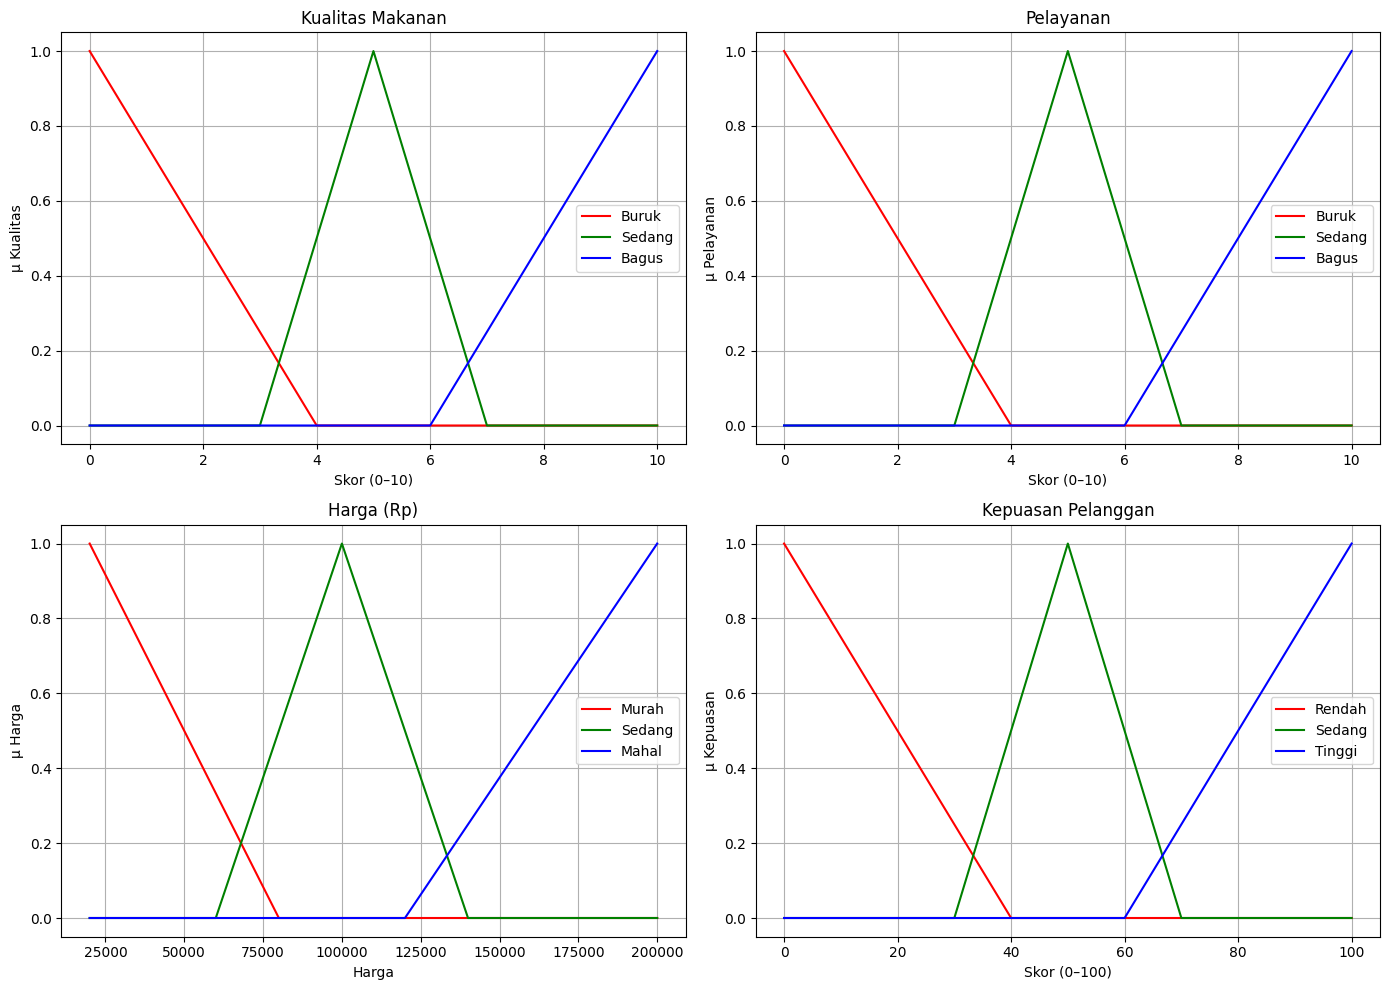

In [54]:
plt.figure(figsize=(14, 10))

# Plot Kualitas
plt.subplot(2, 2, 1)
plt.plot(kualitas, kualitas_buruk, 'r', label='Buruk')
plt.plot(kualitas, kualitas_sedang, 'g', label='Sedang')
plt.plot(kualitas, kualitas_bagus, 'b', label='Bagus')
plt.title('Kualitas Makanan')
plt.xlabel('Skor (0–10)')
plt.ylabel('μ Kualitas')
plt.legend()
plt.grid(True)

# Plot Pelayanan
plt.subplot(2, 2, 2)
plt.plot(pelayanan, pelayanan_buruk, 'r', label='Buruk')
plt.plot(pelayanan, pelayanan_sedang, 'g', label='Sedang')
plt.plot(pelayanan, pelayanan_bagus, 'b', label='Bagus')
plt.title('Pelayanan')
plt.xlabel('Skor (0–10)')
plt.ylabel('μ Pelayanan')
plt.legend()
plt.grid(True)

# Plot Harga
plt.subplot(2, 2, 3)
plt.plot(harga, harga_murah, 'r', label='Murah')
plt.plot(harga, harga_sedang, 'g', label='Sedang')
plt.plot(harga, harga_mahal, 'b', label='Mahal')
plt.title('Harga (Rp)')
plt.xlabel('Harga')
plt.ylabel('μ Harga')
plt.legend()
plt.grid(True)

# Plot Kepuasan
plt.subplot(2, 2, 4)
plt.plot(kepuasan, kepuasan_rendah, 'r', label='Rendah')
plt.plot(kepuasan, kepuasan_sedang, 'g', label='Sedang')
plt.plot(kepuasan, kepuasan_tinggi, 'b', label='Tinggi')
plt.title('Kepuasan Pelanggan')
plt.xlabel('Skor (0–100)')
plt.ylabel('μ Kepuasan')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## **📘Basis Aturan Fuzzy (Rule Base)**

> | No | Aturan Logis                                                                       |
> | -- | ---------------------------------------------------------------------------------- |
> | 1  | IF *Kualitas* Bagus AND *Pelayanan* Bagus AND *Harga* Murah → *Kepuasan* Tinggi    |
> | 2  | IF *Kualitas* Bagus AND *Pelayanan* Sedang AND *Harga* Sedang → *Kepuasan* Tinggi  |
> | 3  | IF *Kualitas* Bagus AND *Pelayanan* Bagus AND *Harga* Mahal → *Kepuasan* Sedang    |
> | 4  | IF *Kualitas* Sedang AND *Pelayanan* Sedang AND *Harga* Sedang → *Kepuasan* Sedang |
> | 5  | IF *Kualitas* Buruk AND *Pelayanan* Buruk AND *Harga* Murah → *Kepuasan* Sedang    |
> | 6  | IF *Kualitas* Buruk AND *Pelayanan* Buruk AND *Harga* Mahal → *Kepuasan* Rendah    |
> | 7  | IF *Kualitas* Sedang AND *Pelayanan* Bagus AND *Harga* Sedang → *Kepuasan* Tinggi  |
> | 8  | IF *Kualitas* Bagus AND *Pelayanan* Buruk AND *Harga* Mahal → *Kepuasan* Sedang    |
> | 9  | IF *Kualitas* Buruk AND *Pelayanan* Sedang AND *Harga* Murah → *Kepuasan* Rendah   |
> | 10 | IF *Kualitas* Sedang AND *Pelayanan* Bagus AND *Harga* Murah → *Kepuasan* Tinggi   |
> | 11 | IF *Kualitas* Sedang AND *Pelayanan* Buruk AND *Harga* Mahal → *Kepuasan* Rendah   |
> | 12 | IF *Kualitas* Bagus AND *Pelayanan* Buruk AND *Harga* Murah → *Kepuasan* Sedang    |
> | 13 | IF *Kualitas* Bagus AND *Pelayanan* Sedang AND *Harga* Mahal → *Kepuasan* Sedang   |
> | 14 | IF *Kualitas* Bagus AND *Pelayanan* Sedang AND *Harga* Murah → *Kepuasan* Tinggi   |


### 💡 *Penjelasan Pola Aturan*

Aturan di atas dirancang untuk menyeimbangkan pengaruh antara *kualitas*, *pelayanan*, dan *harga* secara realistis:

* **Kepuasan Tinggi (Rules 1, 2, 7, 10, 14)**
  → Terjadi saat kualitas & pelayanan bagus dengan harga yang masih tergolong wajar atau murah.

* **Kepuasan Sedang (Rules 3, 4, 5, 8, 12, 13)**
  → Muncul pada kombinasi kualitas bagus tapi harga mahal, atau kondisi pelayanan sedang.

* **Kepuasan Rendah (Rules 6, 9, 11)**
  → Mewakili kasus buruk: kualitas dan pelayanan rendah, atau harga tinggi tanpa diimbangi pelayanan yang baik.



In [83]:
def basis_aturan(derajat_kualitas, derajat_pelayanan, derajat_harga, mf_output):
    """
    derajat_kualitas, derajat_pelayanan, derajat_harga: dict
        contoh: {'buruk': 0.2, 'sedang': 0.7, 'bagus': 0.9}
    mf_output: dict
        contoh: {'rendah': kepuasan_rendah, 'sedang': kepuasan_sedang, 'tinggi': kepuasan_tinggi}
    return: dict of rule outputs
    """
    rules = {}

    # 1. Kualitas Bagus ∧ Pelayanan Bagus ∧ Harga Murah → Kepuasan Tinggi
    r1 = np.fmin(np.fmin(derajat_kualitas['bagus'], derajat_pelayanan['bagus']), derajat_harga['murah'])
    rules['rule1'] = np.fmin(r1, mf_output['tinggi'])

    # 2. Kualitas Bagus ∧ Pelayanan Sedang ∧ Harga Sedang → Kepuasan Tinggi
    r2 = np.fmin(np.fmin(derajat_kualitas['bagus'], derajat_pelayanan['sedang']), derajat_harga['sedang'])
    rules['rule2'] = np.fmin(r2, mf_output['tinggi'])

    # 3. Kualitas Bagus ∧ Pelayanan Bagus ∧ Harga Mahal → Kepuasan Sedang
    r3 = np.fmin(np.fmin(derajat_kualitas['bagus'], derajat_pelayanan['bagus']), derajat_harga['mahal'])
    rules['rule3'] = np.fmin(r3, mf_output['sedang'])

    # 4. Kualitas Sedang ∧ Pelayanan Sedang ∧ Harga Sedang → Kepuasan Sedang
    r4 = np.fmin(np.fmin(derajat_kualitas['sedang'], derajat_pelayanan['sedang']), derajat_harga['sedang'])
    rules['rule4'] = np.fmin(r4, mf_output['sedang'])

    # 5. Kualitas Buruk ∧ Pelayanan Buruk ∧ Harga Murah → Kepuasan Sedang
    r5 = np.fmin(np.fmin(derajat_kualitas['buruk'], derajat_pelayanan['buruk']), derajat_harga['murah'])
    rules['rule5'] = np.fmin(r5, mf_output['sedang'])

    # 6. Kualitas Buruk ∧ Pelayanan Buruk ∧ Harga Mahal → Kepuasan Rendah
    r6 = np.fmin(np.fmin(derajat_kualitas['buruk'], derajat_pelayanan['buruk']), derajat_harga['mahal'])
    rules['rule6'] = np.fmin(r6, mf_output['rendah'])

    # 7. Kualitas Sedang ∧ Pelayanan Bagus ∧ Harga Sedang → Kepuasan Tinggi
    r7 = np.fmin(np.fmin(derajat_kualitas['sedang'], derajat_pelayanan['bagus']), derajat_harga['sedang'])
    rules['rule7'] = np.fmin(r7, mf_output['tinggi'])

    # 8. Kualitas Bagus ∧ Pelayanan Buruk ∧ Harga Mahal → Kepuasan Sedang
    r8 = np.fmin(np.fmin(derajat_kualitas['bagus'], derajat_pelayanan['buruk']), derajat_harga['mahal'])
    rules['rule8'] = np.fmin(r8, mf_output['sedang'])

    # 9. Kualitas Buruk ∧ Pelayanan Sedang ∧ Harga Murah → Kepuasan Rendah
    r9 = np.fmin(np.fmin(derajat_kualitas['buruk'], derajat_pelayanan['sedang']), derajat_harga['murah'])
    rules['rule9'] = np.fmin(r9, mf_output['rendah'])

    # 10. Kualitas Sedang ∧ Pelayanan Bagus ∧ Harga Murah → Kepuasan Tinggi
    r10 = np.fmin(np.fmin(derajat_kualitas['sedang'], derajat_pelayanan['bagus']), derajat_harga['murah'])
    rules['rule10'] = np.fmin(r10, mf_output['tinggi'])

    # 11. Kualitas Sedang ∧ Pelayanan Buruk ∧ Harga Mahal → Kepuasan Rendah
    r11 = np.fmin(np.fmin(derajat_kualitas['sedang'], derajat_pelayanan['buruk']), derajat_harga['mahal'])
    rules['rule11'] = np.fmin(r11, mf_output['rendah'])

    # 12. Kualitas Bagus ∧ Pelayanan Buruk ∧ Harga Murah → Kepuasan Sedang
    r12 = np.fmin(np.fmin(derajat_kualitas['bagus'], derajat_pelayanan['buruk']), derajat_harga['murah'])
    rules['rule12'] = np.fmin(r12, mf_output['sedang'])

     # Bagus ∧ Sedang ∧ Mahal → Sedang
    rules['rule13'] = np.fmin(np.fmin(derajat_kualitas['bagus'], derajat_pelayanan['sedang']), derajat_harga['mahal'])
    rules['rule13'] = np.fmin(rules['rule13'], mf_output['sedang'])

    # Bagus ∧ Sedang ∧ Murah → Tinggi
    rules['rule14'] = np.fmin(np.fmin(derajat_kualitas['bagus'], derajat_pelayanan['sedang']), derajat_harga['murah'])
    rules['rule14'] = np.fmin(rules['rule14'], mf_output['tinggi'])

    for i, (_, v) in enumerate(rules.items(), 1):
        print(f"Rule {i}: max={np.max(v):.3f}")


    return rules


In [84]:
def demo_rules_visualization():
    """
    Visualisasi demonstratif dari 12 rule fuzzy tanpa input spesifik.
    Tujuan: menunjukkan efek clipping (pemotongan) pada fungsi output
    untuk masing-masing rule.

    Catatan:
    - Menggunakan nilai alpha (derajat firing) tetap atau representatif.
    - Cocok untuk laporan / penjelasan teori fuzzy.
    """
    fig, axes = plt.subplots(4, 3, figsize=(18, 14))
    axes = axes.flatten()

    # Daftar aturan dan parameter firing strength (alpha) untuk tiap rule
    rules_demo = [
        ("Kualitas Bagus ∧ Pelayanan Bagus ∧ Harga Murah → Kepuasan Tinggi", 0.7, kepuasan_tinggi),
        ("Kualitas Bagus ∧ Pelayanan Sedang ∧ Harga Sedang → Kepuasan Tinggi", 0.6, kepuasan_tinggi),
        ("Kualitas Bagus ∧ Pelayanan Bagus ∧ Harga Mahal → Kepuasan Sedang", 0.5, kepuasan_sedang),
        ("Kualitas Sedang ∧ Pelayanan Sedang ∧ Harga Sedang → Kepuasan Sedang", 0.6, kepuasan_sedang),
        ("Kualitas Buruk ∧ Pelayanan Buruk ∧ Harga Murah → Kepuasan Sedang", 0.4, kepuasan_sedang),
        ("Kualitas Buruk ∧ Pelayanan Buruk ∧ Harga Mahal → Kepuasan Rendah", 0.8, kepuasan_rendah),
        ("Kualitas Sedang ∧ Pelayanan Bagus ∧ Harga Sedang → Kepuasan Tinggi", 0.7, kepuasan_tinggi),
        ("Kualitas Bagus ∧ Pelayanan Buruk ∧ Harga Mahal → Kepuasan Sedang", 0.5, kepuasan_sedang),
        ("Kualitas Buruk ∧ Pelayanan Sedang ∧ Harga Murah → Kepuasan Rendah", 0.6, kepuasan_rendah),
        ("Kualitas Sedang ∧ Pelayanan Bagus ∧ Harga Murah → Kepuasan Tinggi", 0.8, kepuasan_tinggi),
        ("Kualitas Sedang ∧ Pelayanan Buruk ∧ Harga Mahal → Kepuasan Rendah", 0.5, kepuasan_rendah),
        ("Kualitas Bagus ∧ Pelayanan Buruk ∧ Harga Murah → Kepuasan Sedang", 0.6, kepuasan_sedang)
    ]

    # Plot setiap rule dengan clipping
    for i, (judul, alpha, konsekuen) in enumerate(rules_demo):
        activation = np.fmin(alpha, konsekuen)
        ax = axes[i]
        ax.plot(kepuasan, konsekuen, 'k--', linewidth=0.8, alpha=0.6)
        ax.fill_between(kepuasan, 0, activation, facecolor='orange', alpha=0.7)
        ax.set_title(f"Rule {i+1}: {judul}", fontsize=9)
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 1.05)
        ax.grid(True)

    plt.suptitle("Demonstrasi 12 Rule Fuzzy (Efek Clipping pada Output)", fontsize=14, weight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


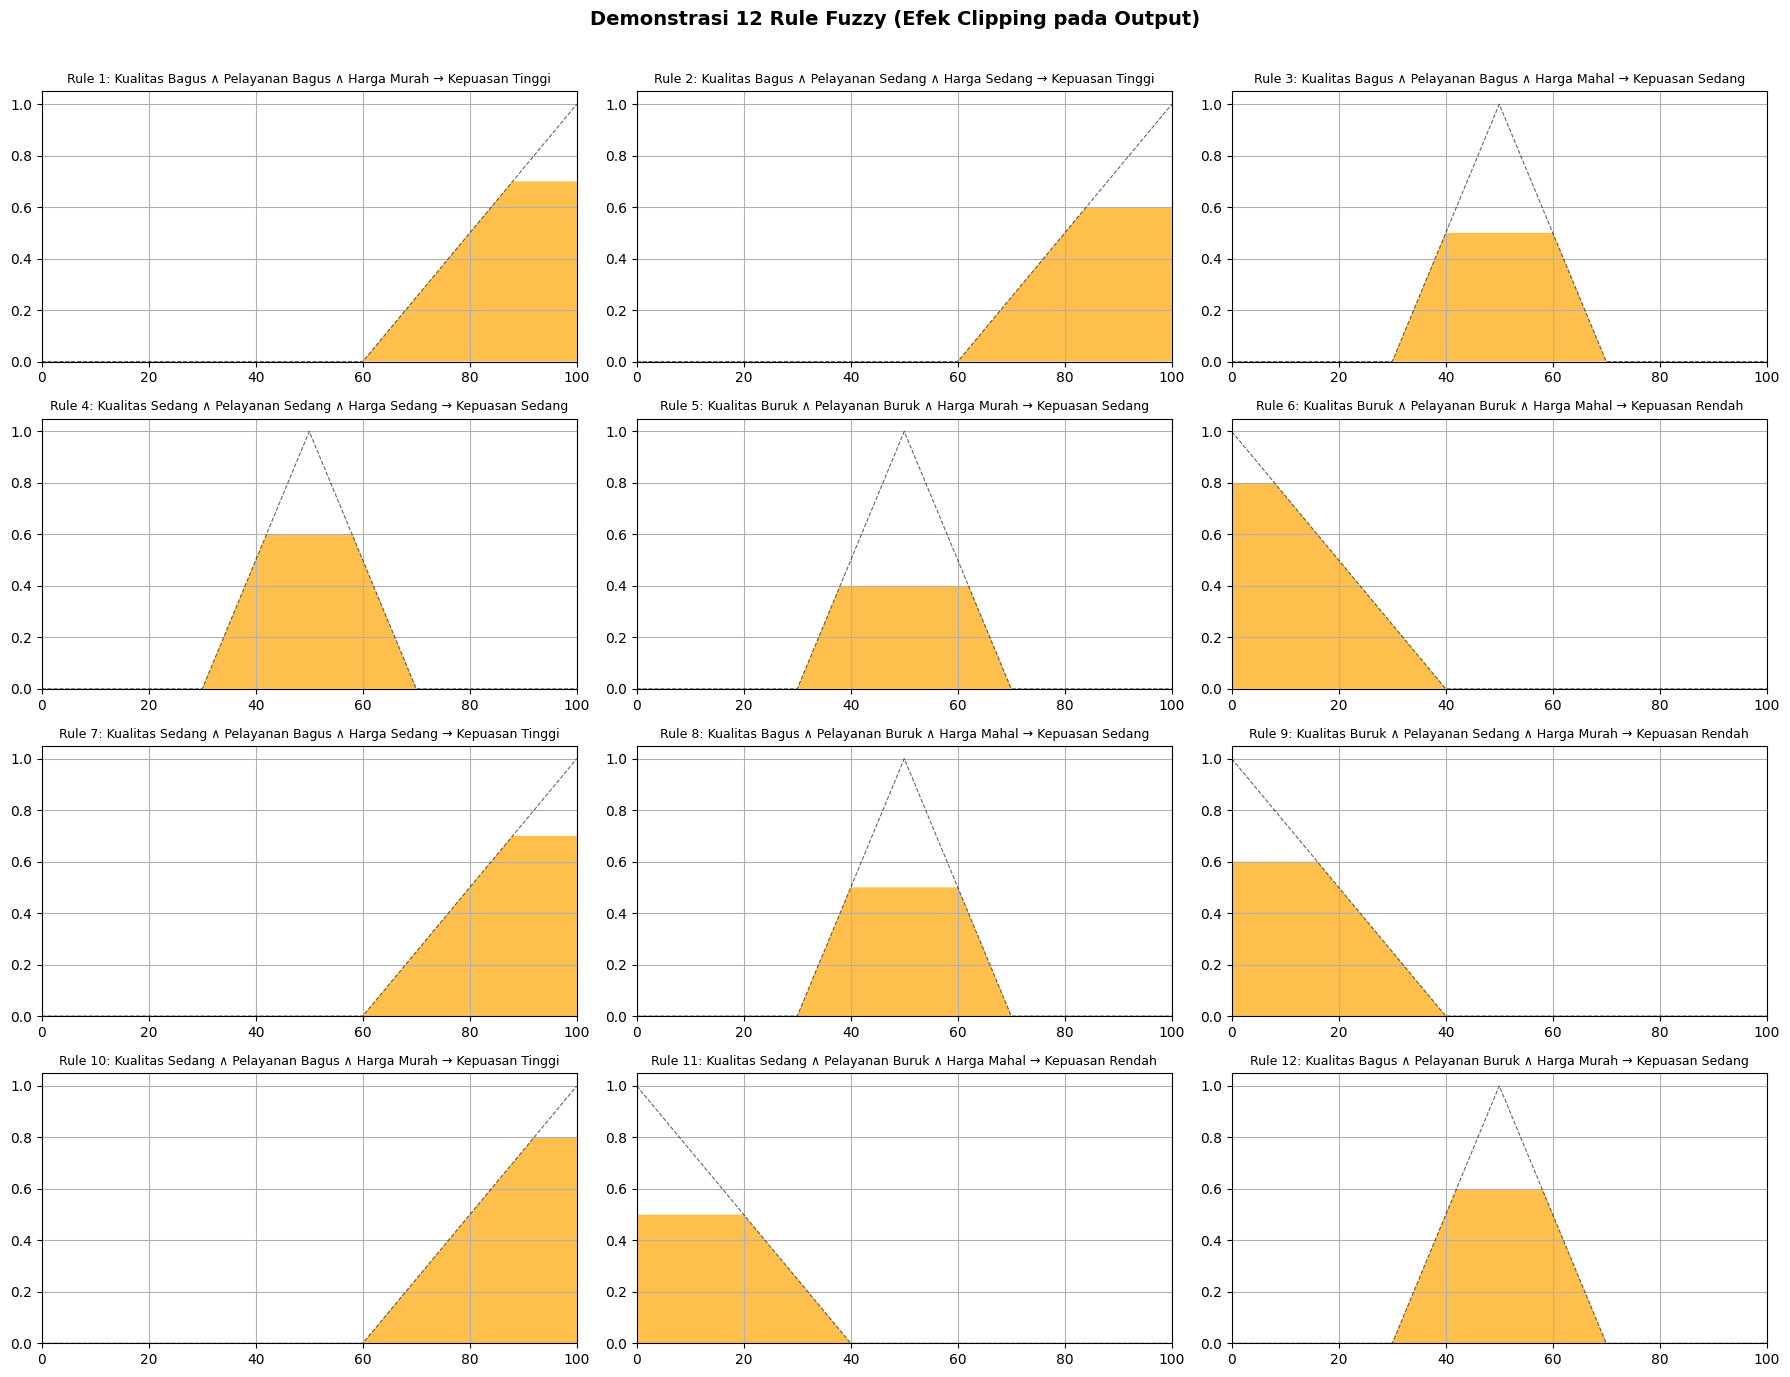

In [85]:
demo_rules_visualization()

In [86]:
def visualisasi_output(domain, aggregated, crisp_value, title="Hasil Fuzzy Mamdani"):
    """
    Menampilkan grafik hasil agregasi fuzzy dan titik defuzzifikasi (centroid).
    domain       : np.array domain output (contoh: kepuasan)
    aggregated   : hasil gabungan dari semua rule
    crisp_value  : nilai defuzzifikasi (centroid)
    """
    plt.figure(figsize=(8, 4))

    
    
    if len(aggregated) != len(domain):
        # Buat garis horizontal sekadar representasi firing strength
        plt.plot(domain, np.ones_like(domain) * 0.5, '--', color='gray', alpha=0.5)
        plt.axvline(crisp_value, color='k', linewidth=2, label='Output Crisp (Weighted Avg)')
        plt.title(title + " — (Representatif Weighted Average)")
        plt.xlabel('Kepuasan (0–100)')
        plt.ylabel('Derajat Keanggotaan')
        plt.legend()
        plt.grid(True)
        plt.show()
        return


    activation = fuzz.interp_membership(domain, aggregated, crisp_value)
    plt.fill_between(domain, 0, aggregated, facecolor='orange', alpha=0.7, label='Agregasi Output')
    plt.plot([crisp_value, crisp_value], [0, activation], 'k', linewidth=2, label='Centroid')
    plt.title(title)
    plt.xlabel('Kepuasan (0–100)')
    plt.ylabel('Derajat Keanggotaan')
    plt.legend()
    plt.grid(True)
    plt.show()


In [87]:
def mamdani(input_kualitas, input_pelayanan, input_harga):
    # Fuzzifikasi input
    derajat_kualitas_buruk = fuzz.interp_membership(kualitas, kualitas_buruk, input_kualitas)
    derajat_kualitas_sedang = fuzz.interp_membership(kualitas, kualitas_sedang, input_kualitas)
    derajat_kualitas_bagus = fuzz.interp_membership(kualitas, kualitas_bagus, input_kualitas)

    derajat_pelayanan_buruk = fuzz.interp_membership(pelayanan, pelayanan_buruk, input_pelayanan)
    derajat_pelayanan_sedang = fuzz.interp_membership(pelayanan, pelayanan_sedang, input_pelayanan)
    derajat_pelayanan_bagus = fuzz.interp_membership(pelayanan, pelayanan_bagus, input_pelayanan)

    derajat_harga_murah = fuzz.interp_membership(harga, harga_murah, input_harga)
    derajat_harga_sedang = fuzz.interp_membership(harga, harga_sedang, input_harga)
    derajat_harga_mahal = fuzz.interp_membership(harga, harga_mahal, input_harga)

    derajat_kualitas = {
    'buruk': derajat_kualitas_buruk,
    'sedang': derajat_kualitas_sedang,
    'bagus': derajat_kualitas_bagus
    }
    derajat_pelayanan = {
        'buruk': derajat_pelayanan_buruk,
        'sedang': derajat_pelayanan_sedang,
        'bagus': derajat_pelayanan_bagus
    }
    derajat_harga = {
        'murah': derajat_harga_murah,
        'sedang': derajat_harga_sedang,
        'mahal': derajat_harga_mahal
    }

    mf_output = {
    'rendah': kepuasan_rendah,
    'sedang': kepuasan_sedang,
    'tinggi': kepuasan_tinggi
    }


    rules = basis_aturan(derajat_kualitas, derajat_pelayanan, derajat_harga, mf_output)
    aggregated_mamdani = np.fmax.reduce(list(rules.values()))

    if np.sum(aggregated_mamdani) == 0:
        output_crisp = 0
        label_dominan = 'tidak terdefinisi'

    else : 
        output_crisp = fuzz.defuzz(kepuasan, aggregated_mamdani, 'centroid')

        dom_rendah = fuzz.interp_membership(kepuasan, kepuasan_rendah, output_crisp)
        dom_sedang = fuzz.interp_membership(kepuasan, kepuasan_sedang, output_crisp)
        dom_tinggi = fuzz.interp_membership(kepuasan, kepuasan_tinggi, output_crisp)

        derajat_label = {
        'rendah': dom_rendah,
        'sedang': dom_sedang,
        'tinggi': dom_tinggi
        }
        
        label_dominan = max(derajat_label, key=derajat_label.get)

    return {
        'crisp': output_crisp,
        'aggregated': aggregated_mamdani,
        'rules': rules,
        'label': label_dominan,
        'mf_output' : mf_output
    }


    

    





In [88]:
def sugeno(input_kualitas, input_pelayanan, input_harga):
    """
    Sistem Inferensi Fuzzy Sugeno (Weighted Average)
    """
    # 1. Fuzzifikasi input
    
    derajat_kualitas_buruk = fuzz.interp_membership(kualitas, kualitas_buruk, input_kualitas)
    derajat_kualitas_sedang = fuzz.interp_membership(kualitas, kualitas_sedang, input_kualitas)
    derajat_kualitas_bagus = fuzz.interp_membership(kualitas, kualitas_bagus, input_kualitas)

    derajat_pelayanan_buruk = fuzz.interp_membership(pelayanan, pelayanan_buruk, input_pelayanan)
    derajat_pelayanan_sedang = fuzz.interp_membership(pelayanan, pelayanan_sedang, input_pelayanan)
    derajat_pelayanan_bagus = fuzz.interp_membership(pelayanan, pelayanan_bagus, input_pelayanan)

    derajat_harga_murah = fuzz.interp_membership(harga, harga_murah, input_harga)
    derajat_harga_sedang = fuzz.interp_membership(harga, harga_sedang, input_harga)
    derajat_harga_mahal = fuzz.interp_membership(harga, harga_mahal, input_harga)

    
    # 2. Hitung firing strength (a) untuk tiap rule
    
    a1 = np.fmin(np.fmin(derajat_kualitas_bagus, derajat_pelayanan_bagus), derajat_harga_murah)
    a2 = np.fmin(np.fmin(derajat_kualitas_bagus, derajat_pelayanan_sedang), derajat_harga_sedang)
    a3 = np.fmin(np.fmin(derajat_kualitas_bagus, derajat_pelayanan_bagus), derajat_harga_mahal)
    a4 = np.fmin(np.fmin(derajat_kualitas_sedang, derajat_pelayanan_sedang), derajat_harga_sedang)
    a5 = np.fmin(np.fmin(derajat_kualitas_buruk, derajat_pelayanan_buruk), derajat_harga_murah)
    a6 = np.fmin(np.fmin(derajat_kualitas_buruk, derajat_pelayanan_buruk), derajat_harga_mahal)
    a7 = np.fmin(np.fmin(derajat_kualitas_sedang, derajat_pelayanan_bagus), derajat_harga_sedang)
    a8 = np.fmin(np.fmin(derajat_kualitas_bagus, derajat_pelayanan_buruk), derajat_harga_mahal)
    a9 = np.fmin(np.fmin(derajat_kualitas_buruk, derajat_pelayanan_sedang), derajat_harga_murah)
    a10 = np.fmin(np.fmin(derajat_kualitas_sedang, derajat_pelayanan_bagus), derajat_harga_murah)
    a11 = np.fmin(np.fmin(derajat_kualitas_sedang, derajat_pelayanan_buruk), derajat_harga_mahal)
    a12 = np.fmin(np.fmin(derajat_kualitas_bagus, derajat_pelayanan_buruk), derajat_harga_murah)

    a = np.array([a1, a2, a3, a4, a5, a6, a7, a8, a9, a10, a11, a12])

    
    # 3. Output tiap rule (z_i)

    # Menggunakan konstanta representatif (0–100)
    z_i = np.array([75, 75, 50, 50, 50, 25, 75, 50, 25, 75, 25, 50])

    
    # 4. Weighted Average Defuzzifikasi
    if np.sum(a) == 0:
        output_crisp = 0
    else:
        output_crisp = np.sum(a * z_i) / np.sum(a)


    # 5. Tentukan label linguistik
    dom_rendah = fuzz.interp_membership(kepuasan, kepuasan_rendah, output_crisp)
    dom_sedang = fuzz.interp_membership(kepuasan, kepuasan_sedang, output_crisp)
    dom_tinggi = fuzz.interp_membership(kepuasan, kepuasan_tinggi, output_crisp)

    derajat_label = {
        'rendah': dom_rendah,
        'sedang': dom_sedang,
        'tinggi': dom_tinggi
    }
    label_dominan = max(derajat_label, key=derajat_label.get)


    # 6. Return hasil (konsisten dengan pipeline)
    return {
        'crisp': output_crisp,
        'label': label_dominan,
        'aggregated': None,     #Sugeno tidak punya fuzzy output
        'rules': None,          #Tidak perlu visualisasi area per rule
        'mf_output': {
            'rendah': kepuasan_rendah,
            'sedang': kepuasan_sedang,
            'tinggi': kepuasan_tinggi
        }
    }


In [89]:
def tsukamoto(input_kualitas, input_pelayanan, input_harga):
    """
    Sistem Inferensi Fuzzy Tsukamoto (Weighted Average)
    """
    # 1. Fuzzifikasi input
    derajat_kualitas_buruk = fuzz.interp_membership(kualitas, kualitas_buruk, input_kualitas)
    derajat_kualitas_sedang = fuzz.interp_membership(kualitas, kualitas_sedang, input_kualitas)
    derajat_kualitas_bagus = fuzz.interp_membership(kualitas, kualitas_bagus, input_kualitas)

    derajat_pelayanan_buruk = fuzz.interp_membership(pelayanan, pelayanan_buruk, input_pelayanan)
    derajat_pelayanan_sedang = fuzz.interp_membership(pelayanan, pelayanan_sedang, input_pelayanan)
    derajat_pelayanan_bagus = fuzz.interp_membership(pelayanan, pelayanan_bagus, input_pelayanan)

    derajat_harga_murah = fuzz.interp_membership(harga, harga_murah, input_harga)
    derajat_harga_sedang = fuzz.interp_membership(harga, harga_sedang, input_harga)
    derajat_harga_mahal = fuzz.interp_membership(harga, harga_mahal, input_harga)


    # 2. Firing strength (a_i)
    a1 = np.fmin(np.fmin(derajat_kualitas_bagus, derajat_pelayanan_bagus), derajat_harga_murah)
    a2 = np.fmin(np.fmin(derajat_kualitas_bagus, derajat_pelayanan_sedang), derajat_harga_sedang)
    a3 = np.fmin(np.fmin(derajat_kualitas_bagus, derajat_pelayanan_bagus), derajat_harga_mahal)
    a4 = np.fmin(np.fmin(derajat_kualitas_sedang, derajat_pelayanan_sedang), derajat_harga_sedang)
    a5 = np.fmin(np.fmin(derajat_kualitas_buruk, derajat_pelayanan_buruk), derajat_harga_murah)
    a6 = np.fmin(np.fmin(derajat_kualitas_buruk, derajat_pelayanan_buruk), derajat_harga_mahal)
    a7 = np.fmin(np.fmin(derajat_kualitas_sedang, derajat_pelayanan_bagus), derajat_harga_sedang)
    a8 = np.fmin(np.fmin(derajat_kualitas_bagus, derajat_pelayanan_buruk), derajat_harga_mahal)
    a9 = np.fmin(np.fmin(derajat_kualitas_buruk, derajat_pelayanan_sedang), derajat_harga_murah)
    a10 = np.fmin(np.fmin(derajat_kualitas_sedang, derajat_pelayanan_bagus), derajat_harga_murah)
    a11 = np.fmin(np.fmin(derajat_kualitas_sedang, derajat_pelayanan_buruk), derajat_harga_mahal)
    a12 = np.fmin(np.fmin(derajat_kualitas_bagus, derajat_pelayanan_buruk), derajat_harga_murah)

    a = np.array([a1, a2, a3, a4, a5, a6, a7, a8, a9, a10, a11, a12])

    # 3. Tentukan label output tiap rule
    label_rule = ['tinggi', 'tinggi', 'sedang', 'sedang', 'sedang', 'rendah',
                  'tinggi', 'sedang', 'rendah', 'tinggi', 'rendah', 'sedang']


    # 4. Cari nilai crisp (z_i) untuk tiap rule
    z_i = []
    for i, label in enumerate(label_rule):
        if a[i] == 0:
            z_i.append(0)
        else:
            # Ambil fungsi keanggotaan sesuai label
            mf = {
                'rendah': kepuasan_rendah_tsu,
                'sedang': kepuasan_sedang_tsu,
                'tinggi': kepuasan_tinggi_tsu
            }[label]

            # Cari titik di domain kepuasan di mana μ = a[i] (inverse membership)
            μ = mf
            idx = np.argmin(np.abs(μ - a[i]))
            z_i.append(kepuasan[idx])

    z_i = np.array(z_i)


    # 5. Defuzzifikasi Weighted Average
    if np.sum(a) == 0:
        output_crisp = 0
    else:
        output_crisp = np.sum(a * z_i) / np.sum(a)


    # 6. Tentukan label linguistik dominan
    dom_rendah = fuzz.interp_membership(kepuasan, kepuasan_rendah, output_crisp)
    dom_sedang = fuzz.interp_membership(kepuasan, kepuasan_sedang, output_crisp)
    dom_tinggi = fuzz.interp_membership(kepuasan, kepuasan_tinggi, output_crisp)

    derajat_label = {
        'rendah': dom_rendah,
        'sedang': dom_sedang,
        'tinggi': dom_tinggi
    }
    label_dominan = max(derajat_label, key=derajat_label.get)


    # 7. Return hasil (konsisten dengan pipeline)
    return {
        'crisp': output_crisp,
        'label': label_dominan,
        'aggregated': a,  # bisa divisualisasikan sebagai firing strength
        'rules': None,
        'mf_output' : {
        'rendah': kepuasan_rendah_tsu,
        'sedang': kepuasan_sedang_tsu,
        'tinggi': kepuasan_tinggi_tsu
    }

    }


In [90]:
test_cases = [
    (7, 8, 50000),
    (9, 5, 180000),
    (3, 2, 100000),
    (6, 7, 140000),
    (8, 9, 80000),
    (10, 10, 200000),  # edge: semua tinggi
    (0, 0, 20000)      # edge: semua rendah
]


In [91]:
def evaluasi_semua_sistem(cases):
    results = []
    for i, (k, p, h) in enumerate(cases, 1):
        hasil_mamdani = mamdani(k, p, h)
        hasil_sugeno = sugeno(k, p, h)
        hasil_tsukamoto = tsukamoto(k, p, h)

        results.append({
            'Kasus': i,
            'Input (K,P,H)': f"({k}, {p}, {h})",
            'Mamdani (Crisp)': round(hasil_mamdani['crisp'], 2),
            'Mamdani (Label)': hasil_mamdani['label'].capitalize(),
            'Sugeno (Crisp)': round(hasil_sugeno['crisp'], 2),
            'Sugeno (Label)': hasil_sugeno['label'].capitalize(),
            'Tsukamoto (Crisp)': round(hasil_tsukamoto['crisp'], 2),
            'Tsukamoto (Label)': hasil_tsukamoto['label'].capitalize()
        })

        # Visualisasi Mamdani
        visualisasi_output(
            kepuasan, hasil_mamdani['aggregated'], hasil_mamdani['crisp'],
            title=f"Mamdani - Kasus {i}"
        )

        # Visualisasi Tsukamoto (Centroid Style)
        visualisasi_output(
            kepuasan_tsukamoto, hasil_tsukamoto['aggregated'], hasil_tsukamoto['crisp'],
            title=f"Tsukamoto - Kasus {i} (Centroid Style)"
        )

    return results


Rule 1: max=0.250
Rule 2: max=0.000
Rule 3: max=0.000
Rule 4: max=0.000
Rule 5: max=0.000
Rule 6: max=0.000
Rule 7: max=0.000
Rule 8: max=0.000
Rule 9: max=0.000
Rule 10: max=0.000
Rule 11: max=0.000
Rule 12: max=0.000
Rule 13: max=0.000
Rule 14: max=0.000


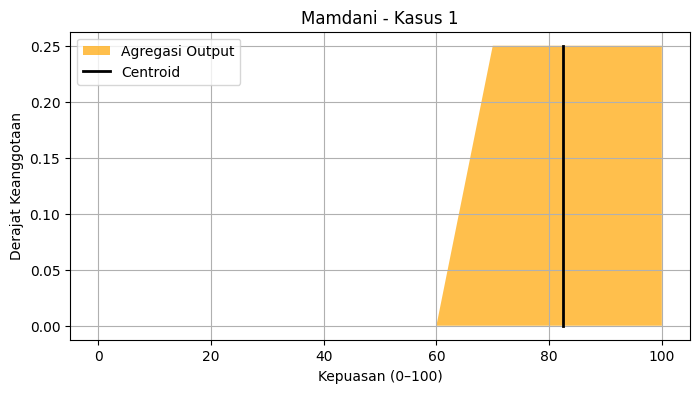

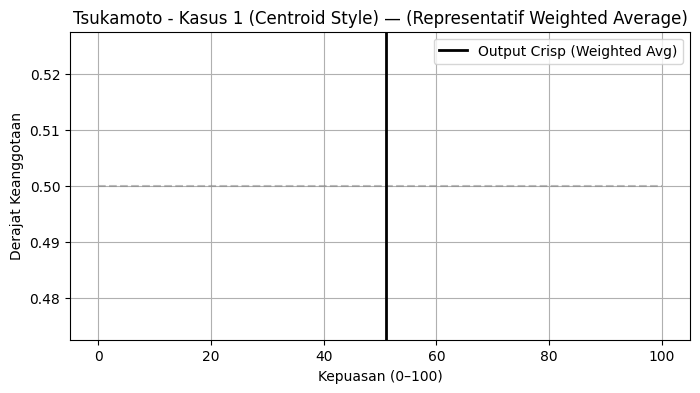

Rule 1: max=0.000
Rule 2: max=0.000
Rule 3: max=0.000
Rule 4: max=0.000
Rule 5: max=0.000
Rule 6: max=0.000
Rule 7: max=0.000
Rule 8: max=0.000
Rule 9: max=0.000
Rule 10: max=0.000
Rule 11: max=0.000
Rule 12: max=0.000
Rule 13: max=0.750
Rule 14: max=0.000


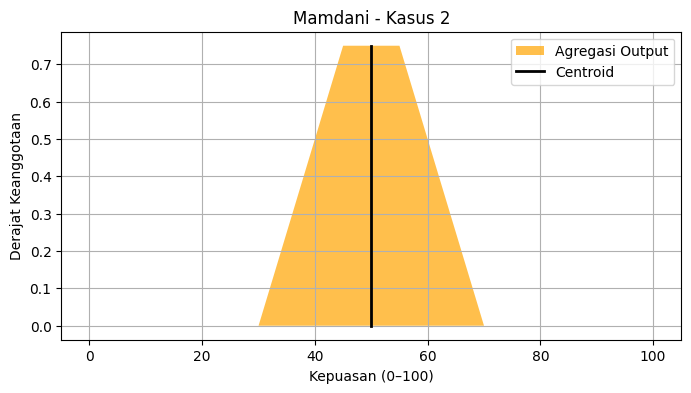

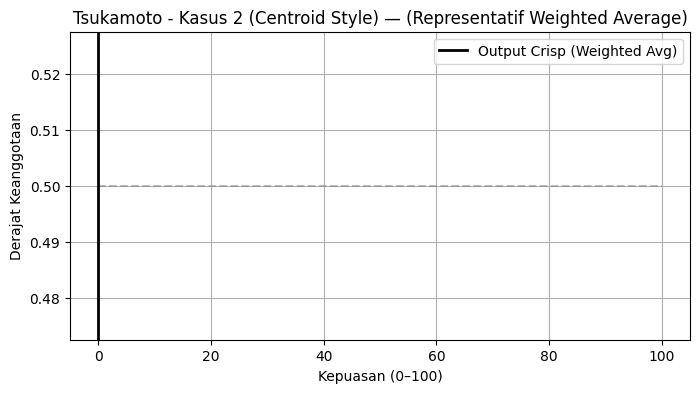

Rule 1: max=0.000
Rule 2: max=0.000
Rule 3: max=0.000
Rule 4: max=0.000
Rule 5: max=0.000
Rule 6: max=0.000
Rule 7: max=0.000
Rule 8: max=0.000
Rule 9: max=0.000
Rule 10: max=0.000
Rule 11: max=0.000
Rule 12: max=0.000
Rule 13: max=0.000
Rule 14: max=0.000


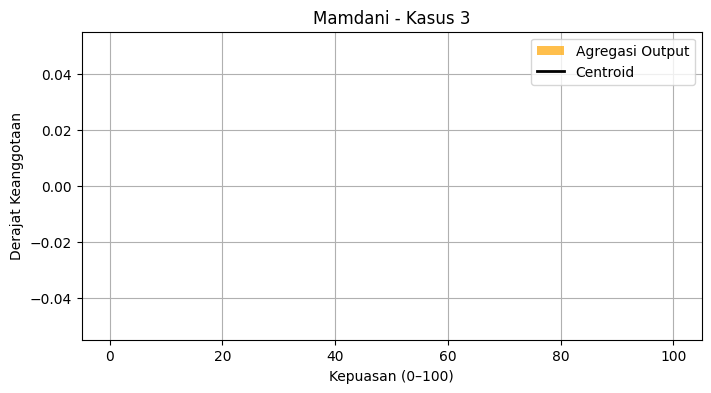

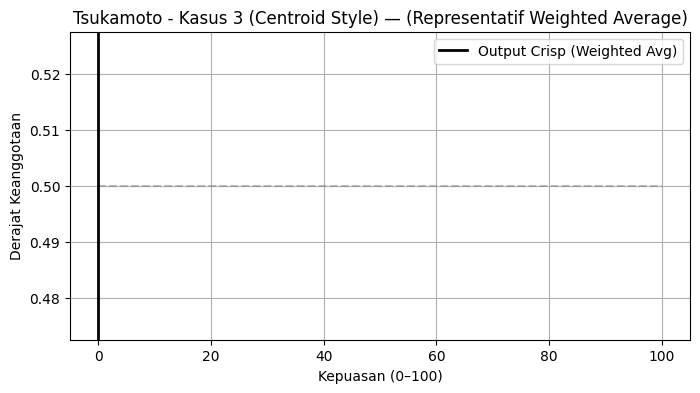

Rule 1: max=0.000
Rule 2: max=0.000
Rule 3: max=0.000
Rule 4: max=0.000
Rule 5: max=0.000
Rule 6: max=0.000
Rule 7: max=0.000
Rule 8: max=0.000
Rule 9: max=0.000
Rule 10: max=0.000
Rule 11: max=0.000
Rule 12: max=0.000
Rule 13: max=0.000
Rule 14: max=0.000


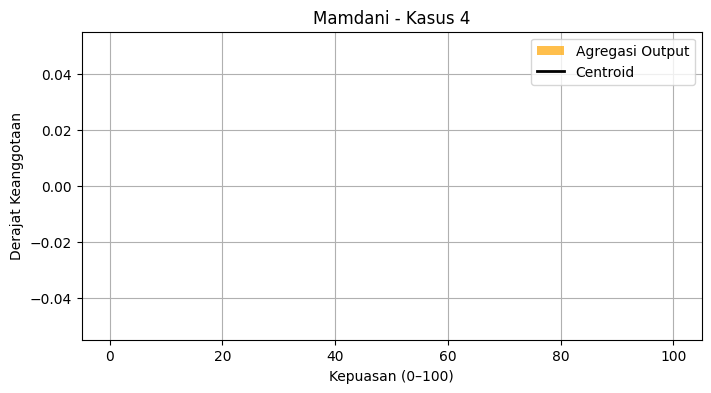

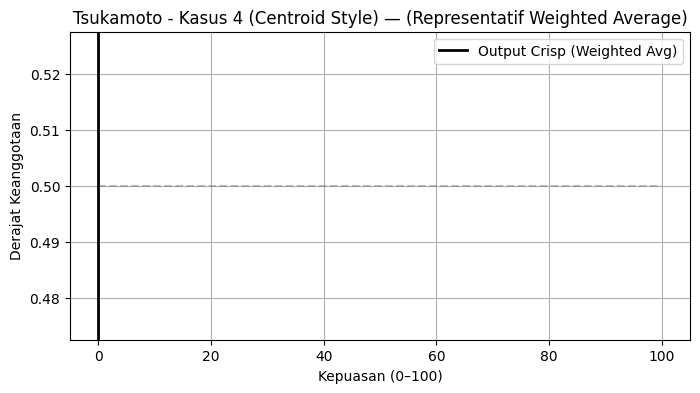

Rule 1: max=0.000
Rule 2: max=0.000
Rule 3: max=0.000
Rule 4: max=0.000
Rule 5: max=0.000
Rule 6: max=0.000
Rule 7: max=0.000
Rule 8: max=0.000
Rule 9: max=0.000
Rule 10: max=0.000
Rule 11: max=0.000
Rule 12: max=0.000
Rule 13: max=0.000
Rule 14: max=0.000


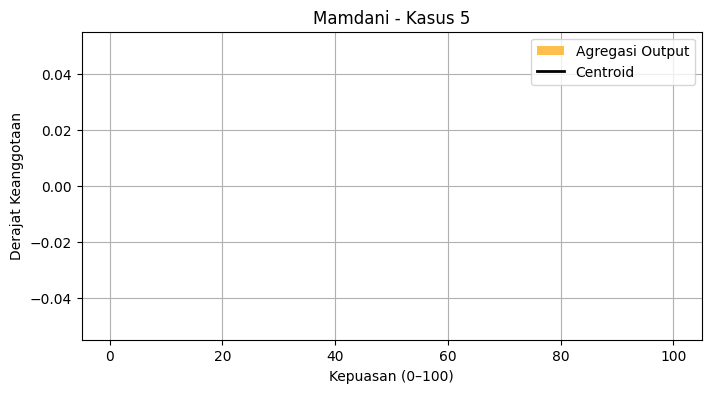

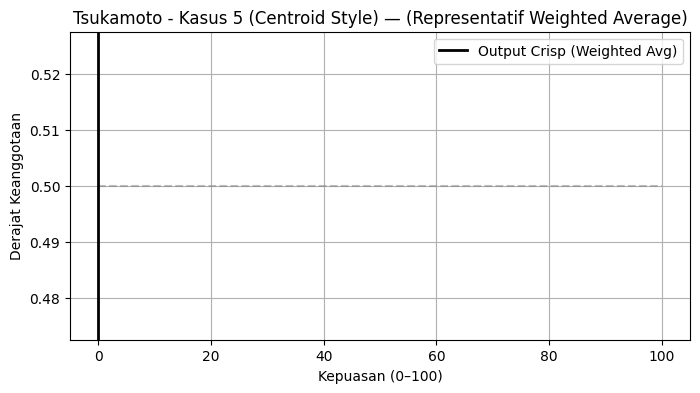

Rule 1: max=0.000
Rule 2: max=0.000
Rule 3: max=1.000
Rule 4: max=0.000
Rule 5: max=0.000
Rule 6: max=0.000
Rule 7: max=0.000
Rule 8: max=0.000
Rule 9: max=0.000
Rule 10: max=0.000
Rule 11: max=0.000
Rule 12: max=0.000
Rule 13: max=0.000
Rule 14: max=0.000


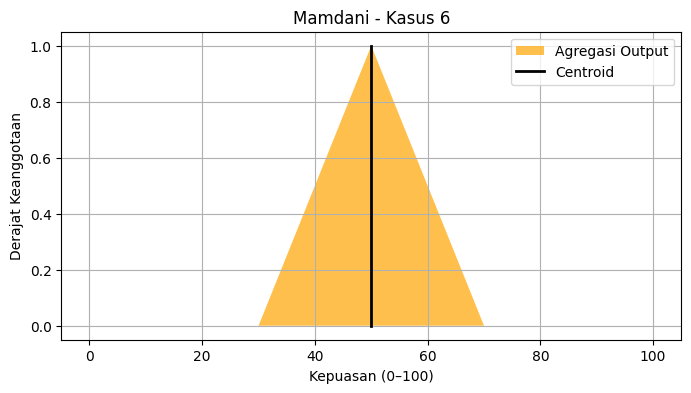

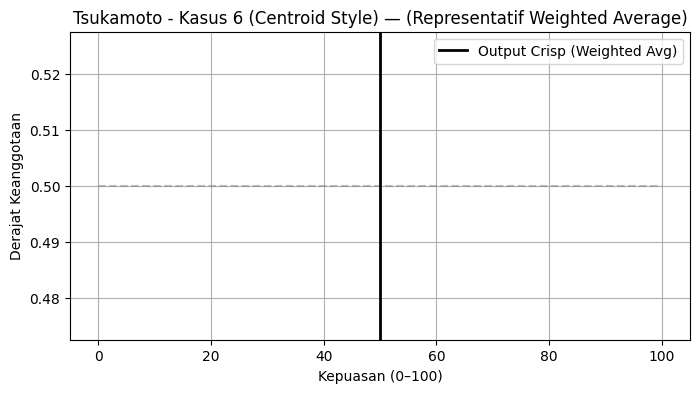

Rule 1: max=0.000
Rule 2: max=0.000
Rule 3: max=0.000
Rule 4: max=0.000
Rule 5: max=1.000
Rule 6: max=0.000
Rule 7: max=0.000
Rule 8: max=0.000
Rule 9: max=0.000
Rule 10: max=0.000
Rule 11: max=0.000
Rule 12: max=0.000
Rule 13: max=0.000
Rule 14: max=0.000


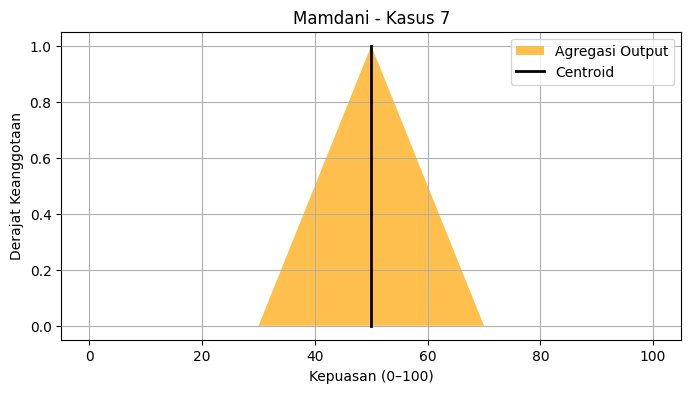

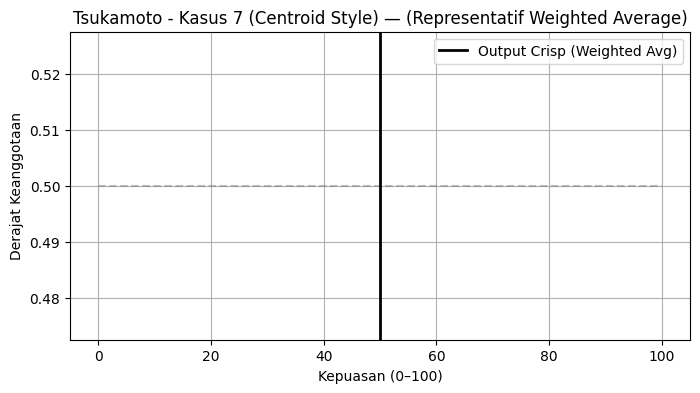

,Kasus,"Input (K,P,H)",Mamdani (Crisp),Mamdani (Label),Sugeno (Crisp),Sugeno (Label),Tsukamoto (Crisp),Tsukamoto (Label)
0,1,"(7, 8, 50000)",82.38,Tinggi,75.0,Tinggi,51.0,Sedang
1,2,"(9, 5, 180000)",50.00,Sedang,0.0,Rendah,0.0,Rendah
2,3,"(3, 2, 100000)",0.00,Tidak terdefinisi,0.0,Rendah,0.0,Rendah
3,4,"(6, 7, 140000)",0.00,Tidak terdefinisi,0.0,Rendah,0.0,Rendah
4,5,"(8, 9, 80000)",0.00,Tidak terdefinisi,0.0,Rendah,0.0,Rendah
5,6,"(10, 10, 200000)",50.00,Sedang,50.0,Sedang,50.0,Sedang
6,7,"(0, 0, 20000)",50.00,Sedang,50.0,Sedang,50.0,Sedang


In [92]:
import pandas as pd

hasil_uji = evaluasi_semua_sistem(test_cases)
df_hasil = pd.DataFrame(hasil_uji)
display(df_hasil)
